# Interpretable Forecasting with N-BEATS

**Docker image**: `ml4t-gpu`

`01_core_architectures` ended on a cost: a network that walks a window one step at a
time pays for the walk and, on that data, bought nothing with it. N-BEATS is the
first of the chapter's answers. It never walks the window. It reads the whole thing
at once through stacked fully connected blocks, and it constrains what each block is
allowed to say, so that the forecast comes out already separated into a slow trend
and a repeating cycle rather than as one opaque number.

The notebook builds the architecture from parts, fits it to SPY closing prices, and
then does two things the architecture invites. It reads the trend and the cycle off
the fitted model separately, which is the payoff for constraining the blocks. And it
scores the forecast against the crudest rule available - repeat today's price - which
is the comparison a flexible architecture has to win before its structure has earned
anything.

**Learning objectives**:
- Build an N-BEATS block: a fully connected stack that emits two vectors, one
  reconstructing its input and one predicting ahead, and understand why subtracting
  the first from the input is what makes a stack of them work.
- Constrain a block's output to a polynomial or to a sum of sine waves, and read the
  resulting forecast as a trend part and a cyclical part you can plot separately.
- Fit the constrained and the unconstrained variants on the same data and say what
  the constraint costs and what it buys.
- Score both against repeating the last price, and measure how far outside its
  training range a trending price series puts the days you are asking about.

**Book Reference**: Chapter 13, Section 13.2 (N-BEATS and explicit decomposition).
Based on Oreshkin et al. (2020), *N-BEATS: Neural Basis Expansion Analysis
for Interpretable Time Series Forecasting*.

**Prerequisites**: `01_core_architectures`; ETF price data via the `load_etfs()`
canonical loader.

In [1]:
"""Interpretable Forecasting with N-BEATS - trend and seasonality decomposition."""

import os
from datetime import datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import torch
import torch.nn as nn
from plotly.subplots import make_subplots

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_plotly_with_alt

In [2]:
SEED = 42
LOOKBACK = 60
HORIZON = 10
HIDDEN_SIZE = 256
N_BLOCKS = 3
N_LAYERS = 4
EPOCHS = 50
BATCH_SIZE = 32
START_DATE = "2015-01-01"

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

set_global_seeds(SEED)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

Using device: cuda


**Reproducibility.** The fixed seed controls stochastic initialization and
mini-batch order. Strict PyTorch kernels and a fixed cuBLAS workspace make
this training path reproducible on the pinned environment; other PyTorch,
CUDA, or hardware versions can still shift the final decimals.

## Data preparation

N-BEATS forecasts one series at a time, so the notebook uses one: the closing price
of SPY, the exchange-traded fund tracking the S&P 500. Prices rather than returns,
because a trend and a seasonal cycle are properties of a level and mostly vanish when
a series is differenced - and a trend is half of what the interpretable configuration
is built to expose.

That choice has a cost, and the notebook measures it rather than assuming it away.
A network's weights are fitted to inputs on a particular numerical scale, so the
prices are standardised - shifted and divided so the training window has mean zero
and standard deviation one. The shift and the scale are computed on the training
window alone; using the whole series would let the network's input scaling carry
information about how high prices eventually went.

In [4]:
etf_df = load_etfs()

start_dt = datetime.fromisoformat(START_DATE)

spy_data = (
    etf_df.filter((pl.col("symbol") == "SPY") & (pl.col("timestamp") >= start_dt))
    .sort("timestamp")
    .select(["timestamp", "close"])
)

prices = spy_data["close"].to_numpy().astype(np.float32)
timestamps = spy_data["timestamp"].to_numpy()

# Boundaries are positions in the price series, so every lookback below is scored on
# the same calendar dates. A sequence belongs to the partition its target falls in.
n_sequences = len(prices) - LOOKBACK - HORIZON + 1
train_target_cutoff = LOOKBACK + int(n_sequences * 0.70)
val_target_cutoff = LOOKBACK + int(n_sequences * 0.85)

# Every training target lies strictly before train_target_cutoff, so that boundary is
# also the last observation the normalization is allowed to read.
price_mean = prices[:train_target_cutoff].mean()
price_std = prices[:train_target_cutoff].std()
prices_norm = (prices - price_mean) / price_std

print(f"SPY: {len(prices)} closes, {timestamps[0]} to {timestamps[-1]}")
print(
    f"Standardized on the first {train_target_cutoff} closes, "
    f"which end {timestamps[train_target_cutoff - 1]}"
)

SPY: 2766 closes, 2015-01-02 to 2025-12-31
Standardized on the first 1947 closes, which end 2022-09-26


### Where the three partitions sit on the standardized scale

The figure below is the one to look at before any result in this notebook. It draws
the standardized price with the three partitions shaded, and marks the highest value
the training window ever reached.

A stationary series would wander across that line in every partition. This one does
not: SPY trends, so the later partitions sit above the earlier one on a scale fitted
to the earlier one. The printed summary gives the ranges. What it says is that the
network is asked to forecast from inputs it has no example of - not unusual inputs,
but values outside the interval it saw at all - and a fully connected network given
an input beyond its training range extrapolates whatever its last layer's slope
happens to be.

This is not a flaw in N-BEATS and it does not go away with a bigger network. It is a
property of standardising a trending level with one shift and one scale for the whole
series. Two standard remedies exist and both appear elsewhere in this chapter:
normalise inside each window instead of globally, which is exactly what N-Linear does
in `03_great_debate`, or difference the series into returns, which is what every
other notebook in the chapter forecasts. Keep it in mind when reading the errors
below - and it is the reason the benchmark to beat is a rule that carries the level
forward rather than one that predicts it.

In [5]:
partitions = {
    "Training": (0, train_target_cutoff),
    "Validation": (train_target_cutoff, val_target_cutoff),
    "Held back": (val_target_cutoff, len(prices)),
}
train_max_z = float(prices_norm[:train_target_cutoff].max())
for name, (lo, hi) in partitions.items():
    z = prices_norm[lo:hi]
    print(
        f"{name:11s} ${prices[lo:hi].min():6.0f}-${prices[lo:hi].max():6.0f}  "
        f"standardized {z.min():+5.2f} to {z.max():+5.2f}"
    )
print(f"\nTraining window never exceeded {train_max_z:+.2f} on the standardized scale.")

Training    $   155-$   451  standardized -1.34 to +2.22
Validation  $   340-$   511  standardized +0.89 to +2.94
Held back   $   491-$   688  standardized +2.70 to +5.08

Training window never exceeded +2.22 on the standardized scale.


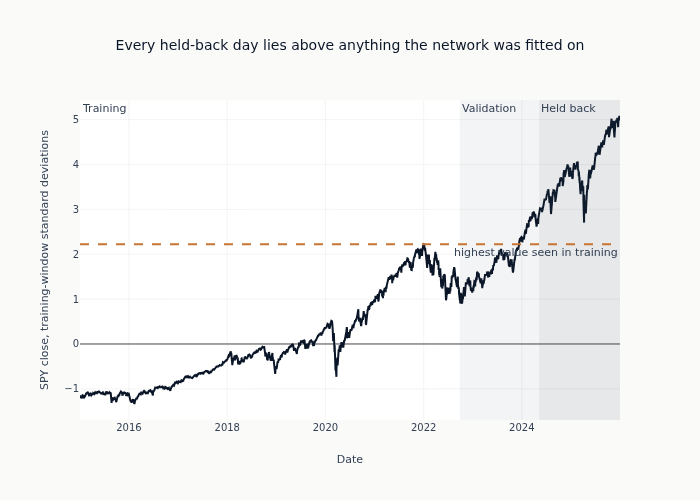

In [6]:
fig_scale = go.Figure()
for (name, (lo, hi)), shade in zip(partitions.items(), [0.0, 0.06, 0.12], strict=True):
    fig_scale.add_vrect(
        x0=timestamps[lo],
        x1=timestamps[hi - 1],
        fillcolor=COLORS["neutral"],
        opacity=shade,
        line_width=0,
        annotation_text=name,
        annotation_position="top left",
    )
fig_scale.add_trace(
    go.Scatter(
        x=timestamps,
        y=prices_norm,
        name="SPY, standardized",
        line=dict(color=COLORS["blue"]),
    )
)
fig_scale.add_hline(
    y=train_max_z,
    line_dash="dash",
    line_color=COLORS["copper"],
    annotation_text="highest value seen in training",
    annotation_position="bottom right",
)
fig_scale.update_layout(
    title="Every held-back day lies above anything the network was fitted on",
    xaxis_title="Date",
    yaxis_title="SPY close, training-window standard deviations",
    showlegend=False,
)
show_plotly_with_alt(
    fig_scale,
    "A line chart of SPY's closing price expressed in training-window standard "
    "deviations, running the length of the sample. Three shaded bands mark the "
    "training, validation and held-back stretches in date order, and a horizontal "
    "dashed line marks the highest value reached during training.",
)

## Building the training examples

One example pairs a `LOOKBACK`-day window of standardized prices with the
`HORIZON` days that follow it. Unlike `01_core_architectures`, where the target was a
single day, the target here is the whole path: N-BEATS emits `HORIZON` numbers at
once rather than being applied repeatedly, which is what lets a polynomial or a sine
wave describe the forecast as a shape.

In [7]:
def create_univariate_sequences(data, lookback, horizon):
    """Create (input, target) pairs for univariate forecasting."""
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback : i + lookback + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


X, y = create_univariate_sequences(prices_norm, LOOKBACK, HORIZON)
print(f"Sequences: X={X.shape}, y={y.shape}")

target_start = np.arange(LOOKBACK, len(prices) - HORIZON + 1)
target_end = target_start + HORIZON - 1

train_mask = target_end < train_target_cutoff
val_mask = (target_start >= train_target_cutoff) & (target_end < val_target_cutoff)
test_mask = target_start >= val_target_cutoff

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
train_val_overlap = max(0, int(target_end[train_mask].max() - target_start[val_mask].min() + 1))
val_test_overlap = max(0, int(target_end[val_mask].max() - target_start[test_mask].min() + 1))
print(
    "Target overlap at train/validation and validation/test boundaries: "
    f"{train_val_overlap}/{val_test_overlap} observations"
)

Sequences: X=(2697, 60), y=(2697, 10)
Train: 1878, Val: 396, Test: 405
Target overlap at train/validation and validation/test boundaries: 0/0 observations


## N-BEATS Block

Each block takes a lookback window as input and produces two outputs:
- **Backcast**: reconstruction of the input (for residual connections)
- **Forecast**: prediction of the future horizon

The interpretable version uses constrained basis functions:
- **Trend stack**: polynomial basis (degree 2-3)
- **Seasonality stack**: Fourier basis

### Basis Expansion Formula

The forecast is generated via basis expansion (Section 13.2):

$$\hat{y} = \sum_{i=1}^{|\theta_f|} \theta_{f,i} \cdot g_{f,i}$$

In the code below:
- `theta_f` (from `self.theta_f(h)`) = learned expansion coefficients
- `T_fore` / `S_fore` = pre-computed basis matrices ($g_f$ vectors)
- `torch.einsum("bp,tp->bt", theta_f, T_fore)` = the weighted sum above

For trend, $g_f = [1, t, t^2, t^3]$ (polynomial); for seasonality,
$g_f = [\sin(2\pi ft), \cos(2\pi ft)]$ (Fourier harmonics).

In [8]:
class NBEATSBlock(nn.Module):
    """Single N-BEATS block with shared FC stack and separate basis projections."""

    def __init__(self, lookback, horizon, hidden_size, n_layers, basis_type="generic"):
        super().__init__()
        self.lookback = lookback
        self.horizon = horizon
        self.basis_type = basis_type

        # Shared fully-connected stack
        layers = [nn.Linear(lookback, hidden_size), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers.extend([nn.Linear(hidden_size, hidden_size), nn.ReLU()])
        self.fc_stack = nn.Sequential(*layers)

        if basis_type == "trend":
            # Polynomial basis: coefficients → polynomial evaluation
            self.poly_degree = 3
            self.theta_b = nn.Linear(hidden_size, self.poly_degree + 1)
            self.theta_f = nn.Linear(hidden_size, self.poly_degree + 1)
            # Pre-compute time vectors
            t_back = torch.linspace(0, 1, lookback).unsqueeze(0)
            t_fore = torch.linspace(0, 1, horizon).unsqueeze(0)
            self.register_buffer(
                "T_back",
                torch.stack([t_back**i for i in range(self.poly_degree + 1)], dim=-1).squeeze(0),
            )
            self.register_buffer(
                "T_fore",
                torch.stack([t_fore**i for i in range(self.poly_degree + 1)], dim=-1).squeeze(0),
            )

        elif basis_type == "seasonality":
            # Fourier basis: coefficients → harmonic evaluation
            self.n_harmonics = 5
            n_coeffs = 2 * self.n_harmonics
            self.theta_b = nn.Linear(hidden_size, n_coeffs)
            self.theta_f = nn.Linear(hidden_size, n_coeffs)
            # Pre-compute Fourier basis
            t_back = torch.linspace(0, 1, lookback).unsqueeze(0)
            t_fore = torch.linspace(0, 1, horizon).unsqueeze(0)
            freqs = torch.arange(1, self.n_harmonics + 1).float()
            self.register_buffer("S_back", self._fourier_basis(t_back, freqs))
            self.register_buffer("S_fore", self._fourier_basis(t_fore, freqs))

        else:  # generic
            self.theta_b = nn.Linear(hidden_size, lookback)
            self.theta_f = nn.Linear(hidden_size, horizon)

    @staticmethod
    def _fourier_basis(t, freqs):
        """Create Fourier basis matrix [sin(2pi*f*t), cos(2pi*f*t)]."""
        # t: (1, T), freqs: (H,) → output: (T, 2H)
        t = t.squeeze(0).unsqueeze(-1)  # (T, 1)
        angles = 2 * np.pi * t * freqs.unsqueeze(0)  # (T, H)
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)  # (T, 2H)

    def forward(self, x):
        h = self.fc_stack(x)

        if self.basis_type == "trend":
            theta_b = self.theta_b(h)  # (batch, poly_degree+1)
            theta_f = self.theta_f(h)
            backcast = torch.einsum("bp,tp->bt", theta_b, self.T_back)
            forecast = torch.einsum("bp,tp->bt", theta_f, self.T_fore)

        elif self.basis_type == "seasonality":
            theta_b = self.theta_b(h)  # (batch, 2*n_harmonics)
            theta_f = self.theta_f(h)
            backcast = torch.einsum("bh,th->bt", theta_b, self.S_back)
            forecast = torch.einsum("bh,th->bt", theta_f, self.S_fore)

        else:  # generic
            backcast = self.theta_b(h)
            forecast = self.theta_f(h)

        return backcast, forecast

## N-BEATS Model

The full model stacks multiple blocks with **doubly-residual** connections:
each block processes the residual from previous blocks (input minus backcast).

In [9]:
class NBEATS(nn.Module):
    """N-BEATS with configurable stacks (interpretable or generic)."""

    def __init__(self, lookback, horizon, hidden_size, n_blocks, n_layers, interpretable=True):
        super().__init__()
        self.blocks = nn.ModuleList()

        if interpretable:
            # Trend stack + Seasonality stack (N-BEATS-I)
            for _ in range(n_blocks):
                self.blocks.append(NBEATSBlock(lookback, horizon, hidden_size, n_layers, "trend"))
            for _ in range(n_blocks):
                self.blocks.append(
                    NBEATSBlock(lookback, horizon, hidden_size, n_layers, "seasonality")
                )
        else:
            # All generic blocks (N-BEATS-G)
            for _ in range(n_blocks * 2):
                self.blocks.append(NBEATSBlock(lookback, horizon, hidden_size, n_layers, "generic"))

    def forward(self, x):
        residual = x
        forecast = torch.zeros(x.shape[0], self.blocks[0].horizon, device=x.device)

        block_forecasts = []
        for block in self.blocks:
            backcast, block_forecast = block(residual)
            residual = residual - backcast  # Doubly-residual: update input
            forecast = forecast + block_forecast  # Accumulate forecasts
            block_forecasts.append(block_forecast)

        return forecast, block_forecasts

## Training

In [10]:
def train_nbeats(model, X_train, y_train, X_val, y_val, epochs, batch_size, lr=1e-3):
    """Train N-BEATS with early stopping."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    X_tr = torch.FloatTensor(X_train).to(DEVICE)
    y_tr = torch.FloatTensor(y_train).to(DEVICE)
    X_v = torch.FloatTensor(X_val).to(DEVICE)
    y_v = torch.FloatTensor(y_val).to(DEVICE)

    best_val_loss = float("inf")
    best_state = None
    patience = 7
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        indices = torch.randperm(len(X_tr))
        epoch_loss = 0.0
        n_batches = 0

        for i in range(0, len(indices), batch_size):
            batch_idx = indices[i : i + batch_size]
            forecast, _ = model(X_tr[batch_idx])
            loss = criterion(forecast, y_tr[batch_idx])

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Prevent exploding gradients
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1

        model.eval()
        with torch.no_grad():
            val_forecast, _ = model(X_v)
            val_loss = criterion(val_forecast, y_v).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"  Epoch {epoch + 1}/{epochs}: train={epoch_loss / n_batches:.6f}, val={val_loss:.6f}"
            )

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch + 1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

## Fitting the two variants

Both are built and trained the same way, and each is **re-seeded immediately before
it is constructed**. That line is easy to leave out and the reason to include it is
not obvious: a network's starting weights are drawn from the global random stream, so
a model built after another one has trained starts from wherever that training left
the stream. The second model's initialization would then depend on how many epochs
the first one happened to run before early stopping - change anything about the
first, and the second starts somewhere else. Re-seeding before each construction
breaks that coupling, so each variant's starting point depends only on `SEED`.

It does not give the two identical weights, which is impossible here: the
interpretable variant's blocks emit a handful of basis coefficients where the generic
variant's emit a full-length vector, so they do not even have the same number of
parameters. What it gives is a starting point that is a property of the seed rather
than of the run that preceded it.

In [11]:
set_global_seeds(SEED)
nbeats_i = NBEATS(LOOKBACK, HORIZON, HIDDEN_SIZE, N_BLOCKS, N_LAYERS, interpretable=True).to(DEVICE)
print(f"N-BEATS-I: {sum(p.numel() for p in nbeats_i.parameters()):,} parameters")
nbeats_i = train_nbeats(nbeats_i, X_train, y_train, X_val, y_val, EPOCHS, BATCH_SIZE)

N-BEATS-I: 1,299,540 parameters


  Epoch 1/50: train=0.050888, val=0.019950


  Epoch 10/50: train=0.005676, val=0.019441


  Early stopping at epoch 12


In [12]:
set_global_seeds(SEED)
nbeats_g = NBEATS(LOOKBACK, HORIZON, HIDDEN_SIZE, N_BLOCKS, N_LAYERS, interpretable=False).to(
    DEVICE
)
print(f"N-BEATS-G: {sum(p.numel() for p in nbeats_g.parameters()):,} parameters")
nbeats_g = train_nbeats(nbeats_g, X_train, y_train, X_val, y_val, EPOCHS, BATCH_SIZE)

N-BEATS-G: 1,385,892 parameters


  Epoch 1/50: train=0.065446, val=0.025021


  Epoch 10/50: train=0.006275, val=0.016212


  Early stopping at epoch 13


## Scoring against the crudest rule available

**Persistence** is the forecast that says tomorrow's price, and every price out to
the end of the horizon, equals today's. It has no parameters and reads nothing but
the last observation. It is also hard to beat on a price series, because a price
moves little from one day to the next relative to how much it moves over a decade,
and it is the benchmark a flexible architecture has to clear before its structure has
demonstrated anything at all.

Two figures are reported. Root mean squared error is in training-window standard
deviations, the units the network works in. The second column divides each model's
mean absolute error by persistence's, so persistence sits at one and anything above
it is a model doing worse than repeating the last number it was given.

In [13]:
X_test_t = torch.FloatTensor(X_test).to(DEVICE)

nbeats_i.eval()
nbeats_g.eval()

with torch.no_grad():
    pred_i, block_forecasts_i = nbeats_i(X_test_t)
    pred_g, _ = nbeats_g(X_test_t)

pred_i = pred_i.cpu().numpy()
pred_g = pred_g.cpu().numpy()

In [14]:
persistence_pred = np.repeat(X_test[:, -1:], HORIZON, axis=1)
persistence_mae = float(np.mean(np.abs(persistence_pred - y_test)))

comparison_df = pl.DataFrame(
    {
        "Model": ["Persistence", "N-BEATS-I", "N-BEATS-G"],
        "RMSE (z)": [
            float(np.sqrt(np.mean((pred - y_test) ** 2)))
            for pred in [persistence_pred, pred_i, pred_g]
        ],
        "MAE / persistence": [
            float(np.mean(np.abs(pred - y_test)) / persistence_mae)
            for pred in [persistence_pred, pred_i, pred_g]
        ],
    }
)

comparison_df

Model,RMSE (z),MAE / persistence
str,f64,f64
"""Persistence""",0.152762,1.0
"""N-BEATS-I""",0.298018,2.34027
"""N-BEATS-G""",0.255549,1.992516


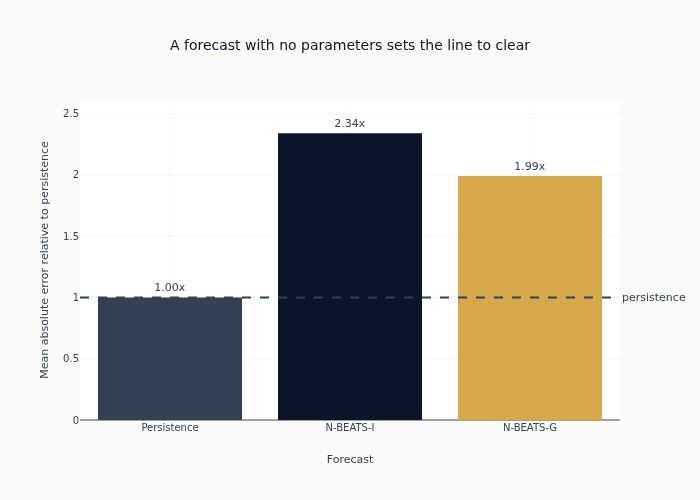

In [15]:
fig_benchmark = go.Figure(
    go.Bar(
        x=comparison_df["Model"].to_list(),
        y=comparison_df["MAE / persistence"].to_list(),
        marker_color=[COLORS["neutral"], COLORS["blue"], COLORS["amber"]],
        text=[f"{value:.2f}x" for value in comparison_df["MAE / persistence"]],
        textposition="outside",
    )
)
fig_benchmark.add_hline(
    y=1.0,
    line_dash="dash",
    line_color=COLORS["neutral"],
    annotation_text="persistence",
    annotation_position="right",
)
fig_benchmark.update_layout(
    title="A forecast with no parameters sets the line to clear",
    xaxis_title="Forecast",
    yaxis_title="Mean absolute error relative to persistence",
    showlegend=False,
)
fig_benchmark.update_yaxes(rangemode="tozero")
show_plotly_with_alt(
    fig_benchmark,
    "A bar chart of three forecasts - persistence and the two N-BEATS variants - "
    "with each bar giving its mean absolute error as a multiple of persistence's, "
    "and a dashed line at one marking persistence itself.",
)

The dashed line is persistence, and a bar above it is a model that would have done
better predicting no change at all. Read that against the standardized-scale figure
near the top: the days being forecast lie outside the range the network was fitted
on, so the network is extrapolating on every one of them while persistence, which
carries the last observed level forward, is unaffected by where that level sits.

What this does and does not license. It does not license a statement about which
architecture forecasts prices better in general - it is one series, one split, one
horizon, and a normalization the section above already identified as unsuited to a
trending level. What it does license is the discipline: a benchmark that costs
nothing goes into every comparison, because without it a plausible-looking error is
uninterpretable, and the interesting property of N-BEATS here is not its accuracy but
what the next section can read out of it.

## Reading the forecast apart

This is what the constrained basis was for. The model's forecast is the sum of every
block's forecast, and the first `N_BLOCKS` blocks can only emit polynomials while the
rest can only emit sums of sine waves. Adding up each group separately therefore
splits the prediction into a slow component and a repeating one, and both are
quantities you can plot rather than a layer's activations you can only stare at.

The generic variant has no such split. Its blocks emit arbitrary vectors, so the sum
is a forecast and the parts are nothing in particular. That difference, not the error
column above, is what the interpretable configuration is bought with.

One window is shown. Any window would do to illustrate the mechanism; the middle of
the held-back stretch is picked so the date is stated rather than chosen for how the
picture came out.

In [16]:
sample_idx = len(X_test) // 2
sample_date = timestamps[val_target_cutoff + sample_idx]
block_preds = [bf[sample_idx].cpu().numpy() for bf in block_forecasts_i]

# Blocks were appended trend-first, so the split matches the construction order.
trend_forecast = sum(block_preds[:N_BLOCKS])
seasonal_forecast = sum(block_preds[N_BLOCKS:])
print(f"Window forecasting the {HORIZON} days from {sample_date}")

Window forecasting the 10 days from 2025-02-28


Putting the components back on the dollar scale takes some care, because the two
halves mean different things. The trend carries the price level, so undoing the
standardization needs both the scale and the shift. The seasonal part is a deviation
around that level, already centred on zero, so it needs the scale only - adding the
training mean to it would move a wiggle of a few dollars up to the price of SPY and
make the panel unreadable.

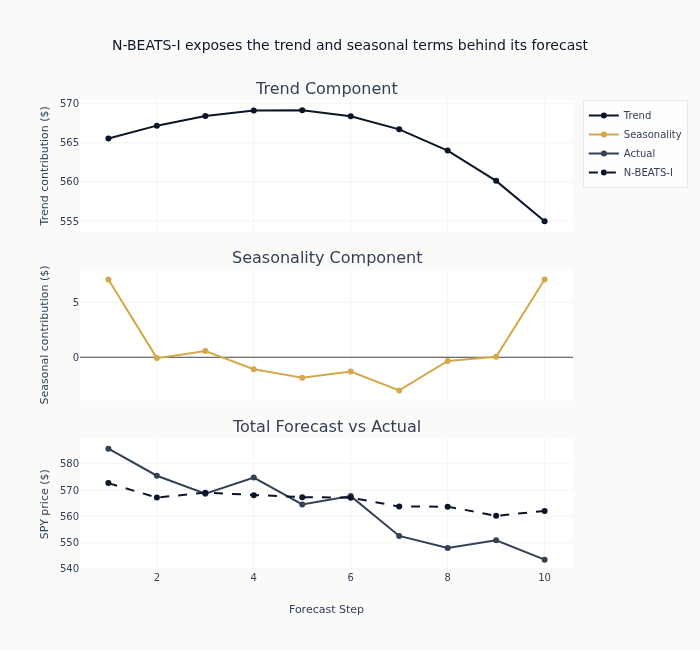

In [17]:
trend_denorm = trend_forecast * price_std + price_mean
seasonal_denorm = seasonal_forecast * price_std  # Zero-centered
total_denorm = pred_i[sample_idx] * price_std + price_mean
actual_denorm = y_test[sample_idx] * price_std + price_mean

x_axis = list(range(1, HORIZON + 1))

fig = make_subplots(
    rows=3,
    cols=1,
    subplot_titles=["Trend Component", "Seasonality Component", "Total Forecast vs Actual"],
    shared_xaxes=True,
    vertical_spacing=0.08,
)

fig.add_trace(
    go.Scatter(x=x_axis, y=trend_denorm, name="Trend", line=dict(color=COLORS["blue"])),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=x_axis,
        y=seasonal_denorm,
        name="Seasonality",
        line=dict(color=COLORS["amber"]),
    ),
    row=2,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=x_axis,
        y=actual_denorm,
        name="Actual",
        line=dict(color=COLORS["neutral"], width=2),
    ),
    row=3,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=x_axis,
        y=total_denorm,
        name="N-BEATS-I",
        line=dict(color=COLORS["blue"], dash="dash"),
    ),
    row=3,
    col=1,
)

fig.update_layout(
    title="N-BEATS-I exposes the trend and seasonal terms behind its forecast",
    height=650,
)
fig.update_xaxes(title_text="Forecast Step", row=3, col=1)
fig.update_yaxes(title_text="Trend contribution ($)", row=1, col=1)
fig.update_yaxes(title_text="Seasonal contribution ($)", row=2, col=1)
fig.update_yaxes(title_text="SPY price ($)", row=3, col=1)
show_plotly_with_alt(
    fig,
    "Three stacked panels over the forecast horizon in days. The top panel plots the "
    "summed trend blocks, the middle the summed seasonality blocks, and the bottom "
    "the realised prices against the model's combined forecast.",
)

## What the blocks left behind

Each block emits a backcast alongside its forecast, and the stack subtracts it before
handing the input to the next block. Running one window through block by block and
keeping the leftover shows what the chain of subtractions did to it.

Two things about that leftover have to be said before the picture, because the
picture invites two wrong readings and the reasons are visible in `forward` above.

**The backcasts were never fitted to reconstruct anything.** The loss is the squared
error of the *forecast*; there is no reconstruction term. A backcast gets a gradient
only through its effect on what later blocks receive, so it is shaped to make the
forecast better, not to explain the input. The leftover is therefore not the part of
the window that a polynomial and five sine waves are unable to represent - it is
whatever these particular backcasts, trained for a different purpose, happened to
leave. Nothing guarantees it is small, and nothing makes a pattern in it evidence
about the basis.

**The last block's backcast head is not trained at all.** Follow it: block six's
backcast is subtracted into `residual`, and `residual` after the final iteration is
returned to nobody and read by nothing. No path connects it to the loss, so its
weights hold their initial random values for the whole of training and its
subtraction is arbitrary. That is a property of stacking blocks under a forecast-only
objective, not a bug in this implementation, and it is why the last subtraction in
the figure below should be read as noise rather than as the stack's final refinement.

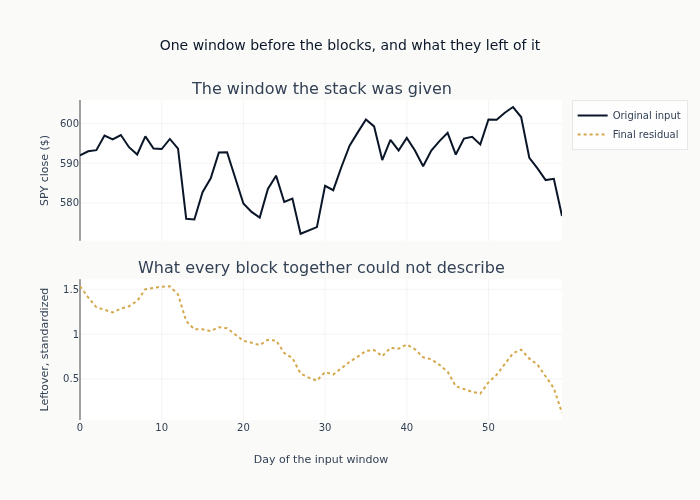

In [18]:
sample_input = torch.FloatTensor(X_test[sample_idx : sample_idx + 1]).to(DEVICE)
nbeats_i.eval()

with torch.no_grad():
    residual = sample_input.clone()
    backcasts = []
    for block in nbeats_i.blocks:
        backcast, _ = block(residual)
        backcasts.append(backcast.cpu().numpy().flatten())
        residual = residual - backcast

# The input goes back to dollars; the leftover stays standardized, because it is not a
# price and adding the training mean to it would put it on the price axis.
input_denorm = X_test[sample_idx] * price_std + price_mean
residual_z = residual.cpu().numpy().flatten()

x_back = list(range(LOOKBACK))

fig_bc = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=[
        "The window the stack was given",
        "What every block together could not describe",
    ],
    shared_xaxes=True,
    vertical_spacing=0.12,
)
fig_bc.add_trace(
    go.Scatter(x=x_back, y=input_denorm, name="Original input", line=dict(width=2)), row=1, col=1
)
fig_bc.add_trace(
    go.Scatter(x=x_back, y=residual_z, name="Final residual", line=dict(dash="dot")), row=2, col=1
)
fig_bc.update_xaxes(title_text="Day of the input window", row=2, col=1)
fig_bc.update_yaxes(title_text="SPY close ($)", row=1, col=1)
fig_bc.update_yaxes(title_text="Leftover, standardized", row=2, col=1)
fig_bc.update_layout(
    title="One window before the blocks, and what they left of it",
    height=500,
)
show_plotly_with_alt(
    fig_bc,
    "Two stacked panels sharing a horizontal axis of position within the input "
    "window. The upper panel plots the window of SPY closes the stack was given, in "
    "dollars; the lower plots what remains after every block has subtracted its "
    "backcast, on a standardized scale.",
)

Read the two panels for scale and shape and stop there. The vertical axes differ, so
the comparison the figure supports is what the subtractions did to this window, not a
measurement of how much of it was explained - and with the last backcast untrained,
part of what is drawn is a random projection of a random head.

The reason to look anyway is that it disciplines how the decomposition figure above
should be read. The trend panel is the model's trend, in the sense the polynomial
constraint gives that word: it is what a block was *allowed* to say while helping the
forecast. It is not a finding that SPY's price contains a cubic trend and a
ten-day cycle. Interpretable here means the output has named parts you can plot, and
that is genuinely more than a generic block offers - it is not a claim that the parts
are the market's.

## How much history to give it

`LOOKBACK` and `HORIZON` are the two settings that decide the shape of the problem,
and their ratio is the one that matters: how many days of history the model is given
per day it has to predict. Too few and a polynomial has almost nothing to fit a
curvature to; too many and most of the window is history the target has no relation
to, which the basis will fit anyway.

There is no way to reason to the right ratio, so it is measured. Four values are
fitted and scored **on the validation windows** - the ones held aside for exactly
this. The held-back stretch is not touched here, and it must not be: a ratio chosen
by looking at it would make every later number a report on a choice already made
using the same data.

Two things are held fixed so the comparison is about the ratio. The target dates are
the same for every candidate, because the boundaries were fixed in the price series
rather than as a fraction of each candidate's own sequence count. And every candidate
starts its training examples on the date the longest window can first reach, so a
difference in error cannot be a difference in how many examples the model saw.

In [19]:
lookback_values = [20, 40, 60, 120]
sweep_first_target = max(lookback_values) + HORIZON - 1
sensitivity_results = []

for lb in lookback_values:
    X_s, y_s = create_univariate_sequences(prices_norm, lb, HORIZON)
    target_start_s = np.arange(lb, len(prices) - HORIZON + 1)
    target_end_s = target_start_s + HORIZON - 1
    train_mask_s = (target_start_s >= sweep_first_target) & (target_end_s < train_target_cutoff)
    val_mask_s = (target_start_s >= train_target_cutoff) & (target_end_s < val_target_cutoff)

    set_global_seeds(SEED)
    model_s = NBEATS(lb, HORIZON, HIDDEN_SIZE, N_BLOCKS, N_LAYERS, interpretable=True).to(DEVICE)
    model_s = train_nbeats(
        model_s,
        X_s[train_mask_s],
        y_s[train_mask_s],
        X_s[val_mask_s],
        y_s[val_mask_s],
        EPOCHS,
        BATCH_SIZE,
    )

    model_s.eval()
    with torch.no_grad():
        pred_s, _ = model_s(torch.FloatTensor(X_s[val_mask_s]).to(DEVICE))
    pred_s = pred_s.cpu().numpy()
    y_s_val = y_s[val_mask_s]
    persistence_s = np.repeat(X_s[val_mask_s, -1:], HORIZON, axis=1)

    rmse_s = float(np.sqrt(np.mean((pred_s - y_s_val) ** 2)))
    mae_ratio_s = float(
        np.mean(np.abs(pred_s - y_s_val)) / np.mean(np.abs(persistence_s - y_s_val))
    )
    sensitivity_results.append(
        {
            "Lookback": lb,
            "Ratio": lb / HORIZON,
            "Validation RMSE (z)": rmse_s,
            "Validation MAE / persistence": mae_ratio_s,
        }
    )
    print(
        f"  {lb} days of history per {HORIZON}-day forecast "
        f"({lb / HORIZON:.0f} to 1), {train_mask_s.sum()} training windows: "
        f"validation RMSE {rmse_s:.4f}, {mae_ratio_s:.2f}x persistence"
    )

sensitivity_df = pl.DataFrame(sensitivity_results)

  Epoch 1/50: train=0.059672, val=0.022167


  Epoch 10/50: train=0.007186, val=0.019906


  Early stopping at epoch 16
  20 days of history per 10-day forecast (2 to 1), 1809 training windows: validation RMSE 0.1105, 1.12x persistence


  Epoch 1/50: train=0.045321, val=0.031925


  Epoch 10/50: train=0.005717, val=0.012375


...

  Epoch 1/50: train=0.059361, val=0.035116


  Epoch 10/50: train=0.005063, val=0.027283


  Early stopping at epoch 14
  60 days of history per 10-day forecast (6 to 1), 1809 training windows: validation RMSE 0.1246, 1.29x persistence


  Epoch 1/50: train=0.062241, val=0.035577


  Early stopping at epoch 8
  120 days of history per 10-day forecast (12 to 1), 1809 training windows: validation RMSE 0.1886, 1.94x persistence


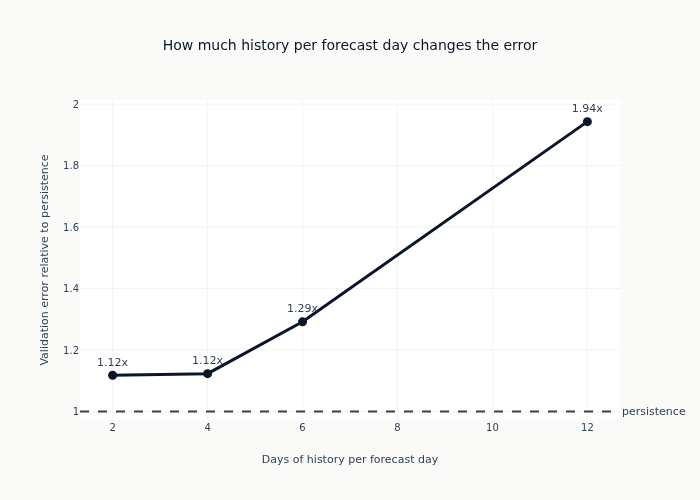

In [20]:
fig_sensitivity = go.Figure(
    go.Scatter(
        x=sensitivity_df["Ratio"].to_list(),
        y=sensitivity_df["Validation MAE / persistence"].to_list(),
        mode="lines+markers+text",
        line=dict(color=COLORS["blue"], width=3),
        marker=dict(size=9),
        text=[f"{value:.2f}x" for value in sensitivity_df["Validation MAE / persistence"]],
        textposition="top center",
    )
)
fig_sensitivity.add_hline(
    y=1.0,
    line_dash="dash",
    line_color=COLORS["neutral"],
    annotation_text="persistence",
    annotation_position="right",
)
fig_sensitivity.update_layout(
    title="How much history per forecast day changes the error",
    xaxis_title="Days of history per forecast day",
    yaxis_title="Validation error relative to persistence",
    showlegend=False,
)
show_plotly_with_alt(
    fig_sensitivity,
    "A line with four markers, plotting validation error as a multiple of "
    "persistence against the number of history days supplied per forecast day. A "
    "dashed line at one marks persistence.",
)

The curve moves, which is the point: the ratio is a real setting and not a detail,
and a number picked without measuring it is a guess. What the curve is not is a
performance estimate. It is a comparison among candidates, scored on the windows kept
for comparing candidates, and every value on it will be a little optimistic for
exactly that reason - four models were fitted and their scores are all on the page.
That is what the held-back stretch is preserved for, and why nothing in this section
reads it.

## Key takeaways

1. **A backcast is what makes a stack of blocks more than a wider network.** Each
   block subtracts its own account of the input before passing it on, so successive
   blocks work on different things rather than all re-fitting the same window. The
   subtraction is trained only through its effect on the forecast, though - there is
   no reconstruction term in the loss, and the final block's backcast reaches nothing
   at all, so it keeps its initial weights. Check where a component is connected to
   the loss before reading anything into it.
2. **Constraining what a block may output is what buys interpretability.** A block
   that can only emit a polynomial produces something you can call a trend and defend
   the name of; a block that can emit any vector produces a forecast whose parts mean
   nothing separately. The constraint is a choice with a price, and the two variants
   fitted here are what let you see the price.
3. **The components are the model's, not the market's.** The trend and cycle panels
   show what a block was allowed to say while helping the forecast, under a loss that
   scores the forecast and nothing else. Read them as named, plottable parts of an
   output - which a generic block does not give you - and not as a claim that the
   series is a cubic trend plus a ten-day cycle.
4. **Standardizing a trending level puts the forecast outside the training range.**
   Every held-back day here sits above every day the network was fitted on, measured
   at the top of the notebook. A network asked to extrapolate does so with whatever
   slope its last layer happens to have. Normalize inside the window, as
   `03_great_debate`'s N-Linear does, or forecast returns, as the rest of the chapter
   does - but an error measured in a setup like this says more about the setup than
   about the architecture.
5. **A benchmark with no parameters belongs in every comparison.** Persistence costs
   nothing to compute and turns an error that could mean anything into an error you
   can act on.

**Known limitations.** One series, one horizon, one chronological split, one seed,
and no hyperparameter search beyond the ratio sweep. The Fourier basis is fixed at
five harmonics over the forecast window, which can only represent cycles that fit
inside it, and daily equity prices have no strong periodicity for it to find. The
ratio sweep is validation evidence and carries the optimism of having chosen from
four candidates.

**Next**: `03_great_debate` puts architectures of this kind against linear baselines
that fit in a single matrix, on the comparison that reset the field's expectations.